In [1]:
import torch
torch.cuda.empty_cache()

--Install Dependency--

In [2]:
%pip install torch

--Cek Runtime Yang digunakan--

In [3]:
import torch, sys
print("python:", sys.executable)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device count:", torch.cuda.device_count())
    print("device name:", torch.cuda.get_device_name(0))
else:
    print("No CUDA device visible")

python: /usr/bin/python3
torch: 2.11.0+cu128
cuda available: True
device count: 1
device name: NVIDIA A100-SXM4-40GB


--Mount Ke G-Drive--

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import drive

drive.flush_and_unmount()

--Check Library Ultralytics Di Drive--

In [4]:
# Unzip folder ultralytics dari Drive
import os
import zipfile

#zip /content/drive/MyDrive/ultralytics.zip
zip_path = "/content/drive/MyDrive/Yolov12/ultralytics.zip"  # <-- ubah sesuai lokasi zip Anda

# Cek apakah file zip ada
if os.path.exists(zip_path):
    print(f"✓ File zip ditemukan: {zip_path}")
    
    # Unzip ke /content
    extract_to = "/content"
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    
    print(f"✓ Unzip selesai ke: {extract_to}")
    
    # Verifikasi folder ada
    if os.path.exists("/content/ultralytics"):
        print("✓ Folder ultralytics berhasil diunzip")
        print("Isi folder ultralytics:")
        for item in os.listdir("/content/ultralytics")[:10]:  # tampilkan 10 item pertama
            print(f"  - {item}")
    else:
        print("✗ Folder ultralytics belum ada setelah unzip")
else:
    print(f"✗ File zip tidak ditemukan di: {zip_path}")
    print("Pastikan path zip sudah benar")

✓ File zip ditemukan: /content/drive/MyDrive/Yolov12/ultralytics.zip
✓ Unzip selesai ke: /content
✓ Folder ultralytics berhasil diunzip
Isi folder ultralytics:
  - solutions
  - train.py
  - runs
  - data
  - models
  - py.typed
  - utils
  - hub
  - engine
  - optim


**__Install Editor Ultralytics Agar Bisa Dipakai__**

In [5]:
# Install ultralytics dalam mode editable
import subprocess
import os

os.chdir("/content")

# Install paket editable agar Python pakai versi lokal yang diedit
result = subprocess.run(
    ["pip", "install", "-e", "./ultralytics"],
    capture_output=True,
    text=True
)

print("Install ultralytics editable mode:")
print(result.stdout)
if result.stderr:
    print("Warnings/Errors:", result.stderr)

# Verifikasi import
try:
    from ultralytics import YOLO
    print("✓ YOLO berhasil diimport dari ultralytics lokal")
except ImportError as e:
    print(f"✗ Error import YOLO: {e}")

Install ultralytics editable mode:
Obtaining file:///content/ultralytics

Warnings/Errors: ERROR: file:///content/ultralytics does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ YOLO berhasil diimport dari ultralytics lokal


__Cek File Txt__

In [ ]:
import os

LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_derta_v2/data/train/labels"

corrupt_files = []

for file in os.listdir(LABEL_DIR):

    if not file.endswith(".txt"):
        continue

    path = os.path.join(LABEL_DIR, file)

    with open(path, "r") as f:
        lines = f.readlines()

    for line in lines:

        parts = line.strip().split()

        # harus 5 nilai
        if len(parts) != 5:
            corrupt_files.append((file, "Jumlah kolom bukan 5"))
            continue

        try:
            cls, x, y, w, h = map(float, parts)

            # class harus 0-6
            if int(cls) not in range(7):
                corrupt_files.append((file, f"Class invalid: {cls}"))

            # koordinat harus 0-1
            for val in [x, y, w, h]:
                if val < 0 or val > 1:
                    corrupt_files.append((file, f"Koordinat invalid: {val}"))

        except:
            corrupt_files.append((file, "Format tidak bisa dibaca"))

print(f"Total corrupt labels: {len(corrupt_files)}")

for item in corrupt_files[:20]:
    print(item)

**Unzip Dataset**

In [6]:
# 📦 UNZIP & SETUP DATASET BARU - Extract dataset zip dan config otomatis
import os
import zipfile
import yaml
import shutil

print("=" * 70)
print("📦 UNZIP & SETUP DATASET BARU")
print("=" * 70)

# ⭐ UBAH PATH INI SESUAI LOKASI ZIP FILE ANDA DI DRIVE
DATASET_ZIP_PATH = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta.zip"  # <-- UBAH SESUAI LOKASI
EXTRACT_TO_PATH = "/content/drive/MyDrive/Dataset_Terbaru"  # Extract ke folder MyDrive
DATASET_NAME = "data_coffe_augmentasi_derta"  # Nama folder hasil extract

print(f"\n1️⃣ Cek file zip:")
if os.path.exists(DATASET_ZIP_PATH):
    print(f"   ✓ File zip ditemukan: {DATASET_ZIP_PATH}")
    
    # Informasi size
    file_size_mb = os.path.getsize(DATASET_ZIP_PATH) / (1024 * 1024)
    print(f"   📊 Ukuran: {file_size_mb:.2f} MB")
    
    print(f"\n2️⃣ Unzip dataset...")
    try:
        # Buat folder tujuan extract
        dataset_extract_path = os.path.join(
            EXTRACT_TO_PATH,
            DATASET_NAME,
            "data"
        )
        os.makedirs(dataset_extract_path, exist_ok=True)

        # Extract zip
        with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(dataset_extract_path)

        print(f"   ✓ Unzip selesai ke: {dataset_extract_path}")
    except Exception as e:
        print(f"   ❌ Error unzip: {e}")
        print(f"   Pastikan file zip tidak corrupt")
        raise
    
    # Cek hasil extract
    print(f"\n3️⃣ Verifikasi folder hasil extract:")
    dataset_path = dataset_extract_path
    
    if os.path.exists(dataset_path):
        print(f"   ✓ Folder {DATASET_NAME}/ ada di {dataset_path}")
        
        # List struktur
        print(f"\n4️⃣ Struktur folder:")
        root_items = os.listdir(dataset_path)
        root_items.sort()
        
        data_config = {'nc': 0, 'names': []}
        
        for item in root_items:
            item_path = os.path.join(dataset_path, item)
            
            if os.path.isdir(item_path):
                sub_items = os.listdir(item_path)
                has_images = 'images' in sub_items
                has_labels = 'labels' in sub_items
                
                if has_images or has_labels:
                    img_count = len(os.listdir(os.path.join(item_path, 'images'))) if has_images else 0
                    lbl_count = len(os.listdir(os.path.join(item_path, 'labels'))) if has_labels else 0
                    print(f"   📁 {item:12} : {img_count:4} images, {lbl_count:4} labels")
            else:
                # Jika ada file (seperti data.yaml)
                if item.endswith('.yaml') or item.endswith('.yml'):
                    print(f"   📄 {item}")
                    
                    # Baca config dari file
                    try:
                        with open(item_path, 'r') as f:
                            file_config = yaml.safe_load(f)
                        if file_config:
                            data_config['nc'] = file_config.get('nc', 0)
                            data_config['names'] = file_config.get('names', [])
                    except:
                        pass
        
        # Buat/Update data.yaml
        print(f"\n5️⃣ Setup data.yaml:")
        
        # Cari folder yang ada (train/val/test/valid)
        # Cari folder yang ada (train/val/test/valid)
        # Cari folder yang ada (khusus cross validation)
        available_folders = [
            f for f in os.listdir(dataset_path)
            if os.path.isdir(os.path.join(dataset_path, f))
            and f in ['train', 'test']
        ]
        
        if available_folders:
            # Mapping nama folder
            # Build data.yaml config khusus cross validation
            new_config = {
                'path': dataset_path,
                'train': 'train/images',
                'test': 'test/images',
                'nc': data_config.get('nc', 0),
                'names': data_config.get('names', [])
            }
            
            # Simpan data.yaml
            data_yaml_path = os.path.join(dataset_path, 'data.yaml')
            with open(data_yaml_path, 'w') as f:
                yaml.dump(new_config, f, default_flow_style=False, sort_keys=False)
            
            print(f"   ✓ data.yaml dibuat/updated: {data_yaml_path}")
            print(f"\n6️⃣ Isi data.yaml:")
            with open(data_yaml_path, 'r') as f:
                print(f.read())
            
            print(f"\n✅ DATASET SIAP DIGUNAKAN!")
            print(f"   Path dataset : {dataset_path}")
            print(f"   Path data.yaml : {data_yaml_path}")
        else:
            print(f"   ❌ Tidak ada folder train/test di dataset")
            print(f"   Folder yang ada: {root_items}")
    else:
        print(f"   ❌ Folder {DATASET_NAME} tidak ditemukan")
        print(f"   Available folders di {EXTRACT_TO_PATH}:")
        for item in os.listdir(EXTRACT_TO_PATH)[:10]:
            print(f"      - {item}")
else:
    print(f"   ❌ File zip TIDAK ditemukan: {DATASET_ZIP_PATH}")
    print(f"\n   📝 Langkah:")
    print(f"   1. Upload .zip ke Google Drive (folder MyDrive atau Path yang Anda tentukan)")
    print(f"   2. Update path di variable DATASET_ZIP_PATH")
    print(f"   3. Run cell ini lagi")

print("\n" + "=" * 70)

**Convert Label**

In [7]:
import os

ALL_LABEL_DIRS = [
    "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/labels",
    "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/test/labels",
]

for LABEL_DIR in ALL_LABEL_DIRS:

    print(f"\nProcessing: {LABEL_DIR}")

    for file in os.listdir(LABEL_DIR):

        if not file.endswith(".txt"):
            continue

        path = os.path.join(LABEL_DIR, file)

        new_lines = []

        with open(path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            # minimal polygon
            if len(parts) < 7:
                continue

            cls = parts[0]
            coords = list(map(float, parts[1:]))

            xs = coords[0::2]
            ys = coords[1::2]

            x_min = min(xs)
            x_max = max(xs)

            y_min = min(ys)
            y_max = max(ys)

            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2

            width = x_max - x_min
            height = y_max - y_min

            new_line = f"{cls} {x_center} {y_center} {width} {height}\n"
            new_lines.append(new_line)

        with open(path, "w") as f:
            f.writelines(new_lines)

print("\n✅ Semua label berhasil diubah ke YOLO Detection")

--Train Model--

**Yolo12n-SqueezeNet**

In [5]:
from ultralytics import YOLO
import yaml
import os
import time
import shutil
from pathlib import Path
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import KFold

try:
    # =============================
    # 1. KONFIGURASI DATASET
    # =============================
    print("\n" + "="*70)
    print("K-FOLD DATASET CONFIGURATION")
    print("="*70)

    IMAGE_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/images"
    LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/labels"

    MODEL = "ultralytics/cfg/models/12/yolo12n-squeezenet.yaml"

    EPOCHS = 300
    BATCH_SIZE = 32
    IMAGE_SIZE = 640
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"

    NUM_FOLDS = 5
    START_FOLD = 5

    CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
    ]
    NC = len(CLASS_NAMES)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Device : {device}")

    # =============================
    # 2. AMBIL DATA GAMBAR
    # =============================
    image_files = sorted([
        f for f in os.listdir(IMAGE_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(f"Total images : {len(image_files)}")

    # =============================
    # 3. K-FOLD SETUP
    # =============================
    kf = KFold(
        n_splits=NUM_FOLDS,
        shuffle=True,
        random_state=42
    )

    all_results = []

    # =============================
    # 4. LOOP CROSS VALIDATION
    # =============================
    for fold, (train_idx, val_idx) in enumerate(kf.split(image_files)):
        if fold + 1 < START_FOLD:
            continue

        print("\n" + "="*70)
        print(f"🚀 TRAINING FOLD {fold+1}/{NUM_FOLDS}")
        print("="*70)

        fold_dir = f"/content/fold_{fold+1}"

        train_img_dir = os.path.join(fold_dir, "train/images")
        train_lbl_dir = os.path.join(fold_dir, "train/labels")

        val_img_dir = os.path.join(fold_dir, "valid/images")
        val_lbl_dir = os.path.join(fold_dir, "valid/labels")

        os.makedirs(train_img_dir, exist_ok=True)
        os.makedirs(train_lbl_dir, exist_ok=True)

        os.makedirs(val_img_dir, exist_ok=True)
        os.makedirs(val_lbl_dir, exist_ok=True)

        # =============================
        # COPY TRAIN FILES
        # =============================
        for idx in train_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(train_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(train_lbl_dir, label_name)
            )

        # =============================
        # COPY VALID FILES
        # =============================
        for idx in val_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(val_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(val_lbl_dir, label_name)
            )

        # =============================
        # CREATE data.yaml
        # =============================
        data_yaml = {
            'path': fold_dir,
            'train': 'train/images',
            'val': 'valid/images',
            'nc': NC,
            'names': CLASS_NAMES
        }

        yaml_path = os.path.join(fold_dir, "data.yaml")

        with open(yaml_path, 'w') as f:
            yaml.safe_dump(data_yaml, f)

        # =============================
        # LOAD MODEL
        # =============================
        # =============================
        # LOAD / RESUME MODEL
        # =============================

        model_name = Path(MODEL).stem

        resume_path = f"/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12n-squeezenet/{model_name}_fold_{fold+1}/weights/last.pt"

        if os.path.exists(resume_path):

            print(f"\n🔄 Resume training Fold {fold+1}")

            model = YOLO(resume_path)

            RESUME = True

        else:

            print(f"\n🆕 Training baru Fold {fold+1}")

            model = YOLO(MODEL)

            RESUME = False

        # =============================
        # HITUNG PARAMETER
        # =============================
        total_params = sum(
            p.numel() for p in model.model.parameters()
        )

        trainable_params = sum(
            p.numel()
            for p in model.model.parameters()
            if p.requires_grad
        )

        print("\n🧠 MODEL INFO")
        print("-"*70)

        print(f"Total params      : {total_params:,}")
        print(f"Trainable params  : {trainable_params:,}")

        # =============================
        # TRAINING
        # =============================
        start_time = time.time()

        results_train = model.train(
            data=yaml_path,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMAGE_SIZE,
            optimizer=OPTIMIZER,
            lr0=LEARNING_RATE,
            project="/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12n-squeezenet",
            name=f"{model_name}_fold_{fold+1}",
            exist_ok=True,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=True,
            patience=50,
            save=True,
            resume=RESUME
        )

        train_time = time.time() - start_time

        run_dir = Path(results_train.save_dir)

        best_model_path = run_dir / "weights/best.pt"

        print(f"\n✅ Fold {fold+1} selesai")
        print(f"Training time : {train_time/60:.2f} menit")

        # =============================
        # VALIDASI
        # =============================
        model_best = YOLO(best_model_path)

        val_results = model_best.val(
            data=yaml_path,
            split="val",
            plots=False
        )

        # =============================
        # FPS
        # =============================
        print("\n🎥 MENGHITUNG FPS")

        val_images = [
            os.path.join(val_img_dir, f)
            for f in os.listdir(val_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        inference_times = []

        _ = model_best.predict(
            val_images[0],
            verbose=False
        )

        for img_path in val_images:

            start_inf = time.time()

            _ = model_best.predict(
                source=img_path,
                imgsz=IMAGE_SIZE,
                verbose=False,
                device=0 if torch.cuda.is_available() else 'cpu'
            )

            end_inf = time.time()

            inference_times.append(end_inf - start_inf)

        avg_latency = np.mean(inference_times)

        fps = 1 / avg_latency

        # =============================
        # METRIK
        # =============================
        P = val_results.results_dict.get('metrics/precision(B)', 0)
        R = val_results.results_dict.get('metrics/recall(B)', 0)

        m50 = val_results.results_dict.get('metrics/mAP50(B)', 0)

        m5095 = val_results.results_dict.get(
            'metrics/mAP50-95(B)',
            0
        )

        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

        print("\n📊 HASIL FOLD")
        print("-"*70)

        print(f"Precision : {P:.4f}")
        print(f"Recall    : {R:.4f}")
        print(f"F1-Score  : {F1:.4f}")
        print(f"mAP50     : {m50:.4f}")
        print(f"mAP50-95  : {m5095:.4f}")
        print(f"FPS       : {fps:.2f}")

        # =============================
        # SAVE CSV
        # =============================
        csv_path = run_dir / "results.csv"

        if csv_path.exists():

            df = pd.read_csv(csv_path)

            df["total_params"] = total_params
            df["trainable_params"] = trainable_params
            df["fps"] = fps

            df.to_csv(csv_path, index=False)

            print("✓ results.csv updated")

        # =============================
        # SIMPAN HASIL
        # =============================
        all_results.append([
            fold + 1,
            P,
            R,
            F1,
            m50,
            m5095,
            fps
        ])

    # =============================
    # 5. HASIL AKHIR
    # =============================
    print("\n" + "="*70)
    print("📈 CROSS VALIDATION SUMMARY")
    print("="*70)

    result_df = pd.DataFrame(
        all_results,
        columns=[
            "Fold",
            "Precision",
            "Recall",
            "F1-Score",
            "mAP50",
            "mAP50-95",
            "FPS"
        ]
    )

    print(result_df)

    print("\n📊 RATA-RATA HASIL")
    print("-"*70)

    print(result_df.mean(numeric_only=True))

    summary_csv = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12n-squeezenet/results.csv"

    result_df.to_csv(summary_csv, index=False)

    print(f"\n✓ Summary saved : {summary_csv}")

except Exception as e:
    print(f"\n❌ Error : {e}")

    import traceback
    traceback.print_exc()


K-FOLD DATASET CONFIGURATION
Device : cuda
Total images : 2398

🚀 TRAINING FOLD 5/5

🔄 Resume training Fold 5

🧠 MODEL INFO
----------------------------------------------------------------------
Total params      : 1,805,541
Trainable params  : 0
New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fold_5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_

**Yolo12s-Squeezenet**

In [1]:
from ultralytics import YOLO
import yaml
import os
import time
import shutil
from pathlib import Path
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import KFold

try:
    # =============================
    # 1. KONFIGURASI DATASET
    # =============================
    print("\n" + "="*70)
    print("K-FOLD DATASET CONFIGURATION")
    print("="*70)

    IMAGE_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/images"
    LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/labels"

    MODEL = "ultralytics/cfg/models/12/yolo12s-squeezenet.yaml"

    EPOCHS = 300
    BATCH_SIZE = 32
    IMAGE_SIZE = 640
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"

    NUM_FOLDS = 5
    START_FOLD = 4

    CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
    ]
    NC = len(CLASS_NAMES)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Device : {device}")

    # =============================
    # 2. AMBIL DATA GAMBAR
    # =============================
    image_files = sorted([
        f for f in os.listdir(IMAGE_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(f"Total images : {len(image_files)}")

    # =============================
    # 3. K-FOLD SETUP
    # =============================
    kf = KFold(
        n_splits=NUM_FOLDS,
        shuffle=True,
        random_state=42
    )

    all_results = []

    # =============================
    # 4. LOOP CROSS VALIDATION
    # =============================
    for fold, (train_idx, val_idx) in enumerate(kf.split(image_files)):
        if fold + 1 < START_FOLD:
            continue

        print("\n" + "="*70)
        print(f"🚀 TRAINING FOLD {fold+1}/{NUM_FOLDS}")
        print("="*70)

        fold_dir = f"/content/fold_{fold+1}"

        train_img_dir = os.path.join(fold_dir, "train/images")
        train_lbl_dir = os.path.join(fold_dir, "train/labels")

        val_img_dir = os.path.join(fold_dir, "valid/images")
        val_lbl_dir = os.path.join(fold_dir, "valid/labels")

        os.makedirs(train_img_dir, exist_ok=True)
        os.makedirs(train_lbl_dir, exist_ok=True)

        os.makedirs(val_img_dir, exist_ok=True)
        os.makedirs(val_lbl_dir, exist_ok=True)

        # =============================
        # COPY TRAIN FILES
        # =============================
        for idx in train_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(train_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(train_lbl_dir, label_name)
            )

        # =============================
        # COPY VALID FILES
        # =============================
        for idx in val_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(val_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(val_lbl_dir, label_name)
            )

        # =============================
        # CREATE data.yaml
        # =============================
        data_yaml = {
            'path': fold_dir,
            'train': 'train/images',
            'val': 'valid/images',
            'nc': NC,
            'names': CLASS_NAMES
        }

        yaml_path = os.path.join(fold_dir, "data.yaml")

        with open(yaml_path, 'w') as f:
            yaml.safe_dump(data_yaml, f)

        # =============================
        # LOAD MODEL
        # =============================
        # =============================
        # LOAD / RESUME MODEL
        # =============================

        model_name = Path(MODEL).stem

        resume_path = f"/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12s-squeezenet/{model_name}_fold_{fold+1}/weights/last.pt"

        if os.path.exists(resume_path):

            print(f"\n🔄 Resume training Fold {fold+1}")

            model = YOLO(resume_path)

            RESUME = True

        else:

            print(f"\n🆕 Training baru Fold {fold+1}")

            model = YOLO(MODEL)

            RESUME = False

        # =============================
        # HITUNG PARAMETER
        # =============================
        total_params = sum(
            p.numel() for p in model.model.parameters()
        )

        trainable_params = sum(
            p.numel()
            for p in model.model.parameters()
            if p.requires_grad
        )

        print("\n🧠 MODEL INFO")
        print("-"*70)

        print(f"Total params      : {total_params:,}")
        print(f"Trainable params  : {trainable_params:,}")

        # =============================
        # TRAINING
        # =============================
        start_time = time.time()

        results_train = model.train(
            data=yaml_path,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMAGE_SIZE,
            optimizer=OPTIMIZER,
            lr0=LEARNING_RATE,
            project="/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12s-squeezenet",
            name=f"{model_name}_fold_{fold+1}",
            exist_ok=True,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=True,
            patience=50,
            save=True,
            resume=RESUME
        )

        train_time = time.time() - start_time

        run_dir = Path(results_train.save_dir)

        best_model_path = run_dir / "weights/best.pt"

        print(f"\n✅ Fold {fold+1} selesai")
        print(f"Training time : {train_time/60:.2f} menit")

        # =============================
        # VALIDASI
        # =============================
        model_best = YOLO(best_model_path)

        val_results = model_best.val(
            data=yaml_path,
            split="val",
            plots=False
        )

        # =============================
        # FPS
        # =============================
        print("\n🎥 MENGHITUNG FPS")

        val_images = [
            os.path.join(val_img_dir, f)
            for f in os.listdir(val_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        inference_times = []

        _ = model_best.predict(
            val_images[0],
            verbose=False
        )

        for img_path in val_images:

            start_inf = time.time()

            _ = model_best.predict(
                source=img_path,
                imgsz=IMAGE_SIZE,
                verbose=False,
                device=0 if torch.cuda.is_available() else 'cpu'
            )

            end_inf = time.time()

            inference_times.append(end_inf - start_inf)

        avg_latency = np.mean(inference_times)

        fps = 1 / avg_latency

        # =============================
        # METRIK
        # =============================
        P = val_results.results_dict.get('metrics/precision(B)', 0)
        R = val_results.results_dict.get('metrics/recall(B)', 0)

        m50 = val_results.results_dict.get('metrics/mAP50(B)', 0)

        m5095 = val_results.results_dict.get(
            'metrics/mAP50-95(B)',
            0
        )

        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

        print("\n📊 HASIL FOLD")
        print("-"*70)

        print(f"Precision : {P:.4f}")
        print(f"Recall    : {R:.4f}")
        print(f"F1-Score  : {F1:.4f}")
        print(f"mAP50     : {m50:.4f}")
        print(f"mAP50-95  : {m5095:.4f}")
        print(f"FPS       : {fps:.2f}")

        # =============================
        # SAVE CSV
        # =============================
        csv_path = run_dir / "results.csv"

        if csv_path.exists():

            df = pd.read_csv(csv_path)

            df["total_params"] = total_params
            df["trainable_params"] = trainable_params
            df["fps"] = fps

            df.to_csv(csv_path, index=False)

            print("✓ results.csv updated")

        # =============================
        # SIMPAN HASIL
        # =============================
        all_results.append([
            fold + 1,
            P,
            R,
            F1,
            m50,
            m5095,
            fps
        ])

    # =============================
    # 5. HASIL AKHIR
    # =============================
    print("\n" + "="*70)
    print("📈 CROSS VALIDATION SUMMARY")
    print("="*70)

    result_df = pd.DataFrame(
        all_results,
        columns=[
            "Fold",
            "Precision",
            "Recall",
            "F1-Score",
            "mAP50",
            "mAP50-95",
            "FPS"
        ]
    )

    print(result_df)

    print("\n📊 RATA-RATA HASIL")
    print("-"*70)

    print(result_df.mean(numeric_only=True))

    summary_csv = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12s-squeezenet/results.csv"

    result_df.to_csv(summary_csv, index=False)

    print(f"\n✓ Summary saved : {summary_csv}")

except Exception as e:
    print(f"\n❌ Error : {e}")

    import traceback
    traceback.print_exc()


K-FOLD DATASET CONFIGURATION
Device : cuda
Total images : 2398

🚀 TRAINING FOLD 4/5

🔄 Resume training Fold 4

🧠 MODEL INFO
----------------------------------------------------------------------
Total params      : 6,299,621
Trainable params  : 0
New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fold_4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_

**Yolo12m-SqueezeNet**

In [6]:
from ultralytics import YOLO
import yaml
import os
import time
import shutil
from pathlib import Path
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import KFold

try:
    # =============================
    # 1. KONFIGURASI DATASET
    # =============================
    print("\n" + "="*70)
    print("K-FOLD DATASET CONFIGURATION")
    print("="*70)

    IMAGE_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/images"
    LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/labels"

    MODEL = "ultralytics/cfg/models/12/yolo12m-squeezenet.yaml"

    EPOCHS = 300
    BATCH_SIZE = 32
    IMAGE_SIZE = 640
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"

    NUM_FOLDS = 5
    # START_FOLD = 3

    CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
    ]
    NC = len(CLASS_NAMES)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Device : {device}")

    # =============================
    # 2. AMBIL DATA GAMBAR
    # =============================
    image_files = sorted([
        f for f in os.listdir(IMAGE_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(f"Total images : {len(image_files)}")

    # =============================
    # 3. K-FOLD SETUP
    # =============================
    kf = KFold(
        n_splits=NUM_FOLDS,
        shuffle=True,
        random_state=42
    )

    all_results = []

    # =============================
    # 4. LOOP CROSS VALIDATION
    # =============================
    for fold, (train_idx, val_idx) in enumerate(kf.split(image_files)):
        # if fold + 1 < START_FOLD:
            # continue

        print("\n" + "="*70)
        print(f"🚀 TRAINING FOLD {fold+1}/{NUM_FOLDS}")
        print("="*70)

        fold_dir = f"/content/fold_{fold+1}"

        train_img_dir = os.path.join(fold_dir, "train/images")
        train_lbl_dir = os.path.join(fold_dir, "train/labels")

        val_img_dir = os.path.join(fold_dir, "valid/images")
        val_lbl_dir = os.path.join(fold_dir, "valid/labels")

        os.makedirs(train_img_dir, exist_ok=True)
        os.makedirs(train_lbl_dir, exist_ok=True)

        os.makedirs(val_img_dir, exist_ok=True)
        os.makedirs(val_lbl_dir, exist_ok=True)

        # =============================
        # COPY TRAIN FILES
        # =============================
        for idx in train_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(train_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(train_lbl_dir, label_name)
            )

        # =============================
        # COPY VALID FILES
        # =============================
        for idx in val_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(val_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(val_lbl_dir, label_name)
            )

        # =============================
        # CREATE data.yaml
        # =============================
        data_yaml = {
            'path': fold_dir,
            'train': 'train/images',
            'val': 'valid/images',
            'nc': NC,
            'names': CLASS_NAMES
        }

        yaml_path = os.path.join(fold_dir, "data.yaml")

        with open(yaml_path, 'w') as f:
            yaml.safe_dump(data_yaml, f)

        # =============================
        # LOAD MODEL
        # =============================
        # =============================
        # LOAD / RESUME MODEL
        # =============================

        model_name = Path(MODEL).stem

        resume_path = f"/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m-squeezenet/{model_name}_fold_{fold+1}/weights/last.pt"

        if os.path.exists(resume_path):

            print(f"\n🔄 Resume training Fold {fold+1}")

            model = YOLO(resume_path)

            RESUME = True

        else:

            print(f"\n🆕 Training baru Fold {fold+1}")

            model = YOLO(MODEL)

            RESUME = False

        # =============================
        # HITUNG PARAMETER
        # =============================
        total_params = sum(
            p.numel() for p in model.model.parameters()
        )

        trainable_params = sum(
            p.numel()
            for p in model.model.parameters()
            if p.requires_grad
        )

        print("\n🧠 MODEL INFO")
        print("-"*70)

        print(f"Total params      : {total_params:,}")
        print(f"Trainable params  : {trainable_params:,}")

        # =============================
        # TRAINING
        # =============================
        start_time = time.time()

        results_train = model.train(
            data=yaml_path,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMAGE_SIZE,
            optimizer=OPTIMIZER,
            lr0=LEARNING_RATE,
            project="/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m-squeezenet",
            name=f"{model_name}_fold_{fold+1}",
            exist_ok=True,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=True,
            patience=50,
            save=True,
            # resume=RESUME
        )

        train_time = time.time() - start_time

        run_dir = Path(results_train.save_dir)

        best_model_path = run_dir / "weights/best.pt"

        print(f"\n✅ Fold {fold+1} selesai")
        print(f"Training time : {train_time/60:.2f} menit")

        # =============================
        # VALIDASI
        # =============================
        model_best = YOLO(best_model_path)

        val_results = model_best.val(
            data=yaml_path,
            split="val",
            plots=False
        )

        # =============================
        # FPS
        # =============================
        print("\n🎥 MENGHITUNG FPS")

        val_images = [
            os.path.join(val_img_dir, f)
            for f in os.listdir(val_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        inference_times = []

        _ = model_best.predict(
            val_images[0],
            verbose=False
        )

        for img_path in val_images:

            start_inf = time.time()

            _ = model_best.predict(
                source=img_path,
                imgsz=IMAGE_SIZE,
                verbose=False,
                device=0 if torch.cuda.is_available() else 'cpu'
            )

            end_inf = time.time()

            inference_times.append(end_inf - start_inf)

        avg_latency = np.mean(inference_times)

        fps = 1 / avg_latency

        # =============================
        # METRIK
        # =============================
        P = val_results.results_dict.get('metrics/precision(B)', 0)
        R = val_results.results_dict.get('metrics/recall(B)', 0)

        m50 = val_results.results_dict.get('metrics/mAP50(B)', 0)

        m5095 = val_results.results_dict.get(
            'metrics/mAP50-95(B)',
            0
        )

        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

        print("\n📊 HASIL FOLD")
        print("-"*70)

        print(f"Precision : {P:.4f}")
        print(f"Recall    : {R:.4f}")
        print(f"F1-Score  : {F1:.4f}")
        print(f"mAP50     : {m50:.4f}")
        print(f"mAP50-95  : {m5095:.4f}")
        print(f"FPS       : {fps:.2f}")

        # =============================
        # SAVE CSV
        # =============================
        csv_path = run_dir / "results.csv"

        if csv_path.exists():

            df = pd.read_csv(csv_path)

            df["total_params"] = total_params
            df["trainable_params"] = trainable_params
            df["fps"] = fps

            df.to_csv(csv_path, index=False)

            print("✓ results.csv updated")

        # =============================
        # SIMPAN HASIL
        # =============================
        all_results.append([
            fold + 1,
            P,
            R,
            F1,
            m50,
            m5095,
            fps
        ])

    # =============================
    # 5. HASIL AKHIR
    # =============================
    print("\n" + "="*70)
    print("📈 CROSS VALIDATION SUMMARY")
    print("="*70)

    result_df = pd.DataFrame(
        all_results,
        columns=[
            "Fold",
            "Precision",
            "Recall",
            "F1-Score",
            "mAP50",
            "mAP50-95",
            "FPS"
        ]
    )

    print(result_df)

    print("\n📊 RATA-RATA HASIL")
    print("-"*70)

    print(result_df.mean(numeric_only=True))

    summary_csv = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m-squeezenet/results.csv"

    result_df.to_csv(summary_csv, index=False)

    print(f"\n✓ Summary saved : {summary_csv}")

except Exception as e:
    print(f"\n❌ Error : {e}")

    import traceback
    traceback.print_exc()


K-FOLD DATASET CONFIGURATION
Device : cuda
Total images : 2398

🚀 TRAINING FOLD 1/5

🔄 Resume training Fold 1

🧠 MODEL INFO
----------------------------------------------------------------------
Total params      : 15,225,061
Trainable params  : 0
New https://pypi.org/project/ultralytics/8.4.103 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fold_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

**Yolo12l**

In [5]:
from ultralytics import YOLO
import yaml
import os
import time
import shutil
from pathlib import Path
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import KFold

try:
    # =============================
    # 1. KONFIGURASI DATASET
    # =============================
    print("\n" + "="*70)
    print("K-FOLD DATASET CONFIGURATION")
    print("="*70)

    IMAGE_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/images"
    LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/labels"

    MODEL = "ultralytics/cfg/models/12/yolo12l-squeezenet.yaml"

    EPOCHS = 300
    BATCH_SIZE = 32
    IMAGE_SIZE = 640
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"

    NUM_FOLDS = 5
    START_FOLD = 5

    CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
    ]
    NC = len(CLASS_NAMES)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Device : {device}")

    # =============================
    # 2. AMBIL DATA GAMBAR
    # =============================
    image_files = sorted([
        f for f in os.listdir(IMAGE_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(f"Total images : {len(image_files)}")

    # =============================
    # 3. K-FOLD SETUP
    # =============================
    kf = KFold(
        n_splits=NUM_FOLDS,
        shuffle=True,
        random_state=42
    )

    all_results = []

    # =============================
    # 4. LOOP CROSS VALIDATION
    # =============================
    for fold, (train_idx, val_idx) in enumerate(kf.split(image_files)):
        if fold + 1 < START_FOLD:
            continue

        print("\n" + "="*70)
        print(f"🚀 TRAINING FOLD {fold+1}/{NUM_FOLDS}")
        print("="*70)

        fold_dir = f"/content/fold_{fold+1}"

        train_img_dir = os.path.join(fold_dir, "train/images")
        train_lbl_dir = os.path.join(fold_dir, "train/labels")

        val_img_dir = os.path.join(fold_dir, "valid/images")
        val_lbl_dir = os.path.join(fold_dir, "valid/labels")

        os.makedirs(train_img_dir, exist_ok=True)
        os.makedirs(train_lbl_dir, exist_ok=True)

        os.makedirs(val_img_dir, exist_ok=True)
        os.makedirs(val_lbl_dir, exist_ok=True)

        # =============================
        # COPY TRAIN FILES
        # =============================
        for idx in train_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(train_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(train_lbl_dir, label_name)
            )

        # =============================
        # COPY VALID FILES
        # =============================
        for idx in val_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(val_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(val_lbl_dir, label_name)
            )

        # =============================
        # CREATE data.yaml
        # =============================
        data_yaml = {
            'path': fold_dir,
            'train': 'train/images',
            'val': 'valid/images',
            'nc': NC,
            'names': CLASS_NAMES
        }

        yaml_path = os.path.join(fold_dir, "data.yaml")

        with open(yaml_path, 'w') as f:
            yaml.safe_dump(data_yaml, f)

        # =============================
        # LOAD MODEL
        # =============================
        # =============================
        # LOAD / RESUME MODEL
        # =============================

        model_name = Path(MODEL).stem

        resume_path = f"/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12l-squeezenet/{model_name}_fold_{fold+1}/weights/last.pt"

        if os.path.exists(resume_path):

            print(f"\n🔄 Resume training Fold {fold+1}")

            model = YOLO(resume_path)

            RESUME = True

        else:

            print(f"\n🆕 Training baru Fold {fold+1}")

            model = YOLO(MODEL)

            RESUME = False

        # =============================
        # HITUNG PARAMETER
        # =============================
        total_params = sum(
            p.numel() for p in model.model.parameters()
        )

        trainable_params = sum(
            p.numel()
            for p in model.model.parameters()
            if p.requires_grad
        )

        print("\n🧠 MODEL INFO")
        print("-"*70)

        print(f"Total params      : {total_params:,}")
        print(f"Trainable params  : {trainable_params:,}")

        # =============================
        # TRAINING
        # =============================
        start_time = time.time()

        results_train = model.train(
            data=yaml_path,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMAGE_SIZE,
            optimizer=OPTIMIZER,
            lr0=LEARNING_RATE,
            project="/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12l-squeezenet",
            name=f"{model_name}_fold_{fold+1}",
            exist_ok=True,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=True,
            patience=50,
            save=True,
            resume=RESUME
        )

        train_time = time.time() - start_time

        run_dir = Path(results_train.save_dir)

        best_model_path = run_dir / "weights/best.pt"

        print(f"\n✅ Fold {fold+1} selesai")
        print(f"Training time : {train_time/60:.2f} menit")

        # =============================
        # VALIDASI
        # =============================
        model_best = YOLO(best_model_path)

        val_results = model_best.val(
            data=yaml_path,
            split="val",
            plots=False
        )

        # =============================
        # FPS
        # =============================
        print("\n🎥 MENGHITUNG FPS")

        val_images = [
            os.path.join(val_img_dir, f)
            for f in os.listdir(val_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        inference_times = []

        _ = model_best.predict(
            val_images[0],
            verbose=False
        )

        for img_path in val_images:

            start_inf = time.time()

            _ = model_best.predict(
                source=img_path,
                imgsz=IMAGE_SIZE,
                verbose=False,
                device=0 if torch.cuda.is_available() else 'cpu'
            )

            end_inf = time.time()

            inference_times.append(end_inf - start_inf)

        avg_latency = np.mean(inference_times)

        fps = 1 / avg_latency

        # =============================
        # METRIK
        # =============================
        P = val_results.results_dict.get('metrics/precision(B)', 0)
        R = val_results.results_dict.get('metrics/recall(B)', 0)

        m50 = val_results.results_dict.get('metrics/mAP50(B)', 0)

        m5095 = val_results.results_dict.get(
            'metrics/mAP50-95(B)',
            0
        )

        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

        print("\n📊 HASIL FOLD")
        print("-"*70)

        print(f"Precision : {P:.4f}")
        print(f"Recall    : {R:.4f}")
        print(f"F1-Score  : {F1:.4f}")
        print(f"mAP50     : {m50:.4f}")
        print(f"mAP50-95  : {m5095:.4f}")
        print(f"FPS       : {fps:.2f}")

        # =============================
        # SAVE CSV
        # =============================
        csv_path = run_dir / "results.csv"

        if csv_path.exists():

            df = pd.read_csv(csv_path)

            df["total_params"] = total_params
            df["trainable_params"] = trainable_params
            df["fps"] = fps

            df.to_csv(csv_path, index=False)

            print("✓ results.csv updated")

        # =============================
        # SIMPAN HASIL
        # =============================
        all_results.append([
            fold + 1,
            P,
            R,
            F1,
            m50,
            m5095,
            fps
        ])

    # =============================
    # 5. HASIL AKHIR
    # =============================
    print("\n" + "="*70)
    print("📈 CROSS VALIDATION SUMMARY")
    print("="*70)

    result_df = pd.DataFrame(
        all_results,
        columns=[
            "Fold",
            "Precision",
            "Recall",
            "F1-Score",
            "mAP50",
            "mAP50-95",
            "FPS"
        ]
    )

    print(result_df)

    print("\n📊 RATA-RATA HASIL")
    print("-"*70)

    print(result_df.mean(numeric_only=True))

    summary_csv = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12l-squeezenet/results.csv"

    result_df.to_csv(summary_csv, index=False)

    print(f"\n✓ Summary saved : {summary_csv}")

except Exception as e:
    print(f"\n❌ Error : {e}")

    import traceback
    traceback.print_exc()


K-FOLD DATASET CONFIGURATION
Device : cuda
Total images : 2398

🚀 TRAINING FOLD 5/5

🔄 Resume training Fold 5

🧠 MODEL INFO
----------------------------------------------------------------------
Total params      : 17,182,437
Trainable params  : 0
New https://pypi.org/project/ultralytics/8.4.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fold_5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

**YOLO12x-SqueezeNet**

In [5]:
from ultralytics import YOLO
import yaml
import os
import time
import shutil
from pathlib import Path
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import KFold

try:
    # =============================
    # 1. KONFIGURASI DATASET
    # =============================
    print("\n" + "="*70)
    print("K-FOLD DATASET CONFIGURATION")
    print("="*70)

    IMAGE_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/images"
    LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/train/labels"

    MODEL = "ultralytics/cfg/models/12/yolo12x-squeezenet.yaml"

    EPOCHS = 300
    BATCH_SIZE = 32
    IMAGE_SIZE = 640
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"

    NUM_FOLDS = 5
    START_FOLD = 4

    CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
    ]
    NC = len(CLASS_NAMES)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Device : {device}")

    # =============================
    # 2. AMBIL DATA GAMBAR
    # =============================
    image_files = sorted([
        f for f in os.listdir(IMAGE_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(f"Total images : {len(image_files)}")

    # =============================
    # 3. K-FOLD SETUP
    # =============================
    kf = KFold(
        n_splits=NUM_FOLDS,
        shuffle=True,
        random_state=42
    )

    all_results = []

    # =============================
    # 4. LOOP CROSS VALIDATION
    # =============================
    for fold, (train_idx, val_idx) in enumerate(kf.split(image_files)):
        if fold + 1 < START_FOLD:
            continue

        print("\n" + "="*70)
        print(f"🚀 TRAINING FOLD {fold+1}/{NUM_FOLDS}")
        print("="*70)

        fold_dir = f"/content/fold_{fold+1}"

        train_img_dir = os.path.join(fold_dir, "train/images")
        train_lbl_dir = os.path.join(fold_dir, "train/labels")

        val_img_dir = os.path.join(fold_dir, "valid/images")
        val_lbl_dir = os.path.join(fold_dir, "valid/labels")

        os.makedirs(train_img_dir, exist_ok=True)
        os.makedirs(train_lbl_dir, exist_ok=True)

        os.makedirs(val_img_dir, exist_ok=True)
        os.makedirs(val_lbl_dir, exist_ok=True)

        # =============================
        # COPY TRAIN FILES
        # =============================
        for idx in train_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(train_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(train_lbl_dir, label_name)
            )

        # =============================
        # COPY VALID FILES
        # =============================
        for idx in val_idx:

            img_name = image_files[idx]

            shutil.copy(
                os.path.join(IMAGE_DIR, img_name),
                os.path.join(val_img_dir, img_name)
            )

            label_name = Path(img_name).stem + ".txt"

            shutil.copy(
                os.path.join(LABEL_DIR, label_name),
                os.path.join(val_lbl_dir, label_name)
            )

        # =============================
        # CREATE data.yaml
        # =============================
        data_yaml = {
            'path': fold_dir,
            'train': 'train/images',
            'val': 'valid/images',
            'nc': NC,
            'names': CLASS_NAMES
        }

        yaml_path = os.path.join(fold_dir, "data.yaml")

        with open(yaml_path, 'w') as f:
            yaml.safe_dump(data_yaml, f)

        # =============================
        # LOAD MODEL
        # =============================
        # =============================
        # LOAD / RESUME MODEL
        # =============================

        model_name = Path(MODEL).stem

        resume_path = f"/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12x-squeezenet1/{model_name}_fold_{fold+1}/weights/last.pt"

        if os.path.exists(resume_path):

            print(f"\n🔄 Resume training Fold {fold+1}")

            model = YOLO(resume_path)

            RESUME = True

        else:

            print(f"\n🆕 Training baru Fold {fold+1}")

            model = YOLO(MODEL)

            RESUME = False

        # =============================
        # HITUNG PARAMETER
        # =============================
        total_params = sum(
            p.numel() for p in model.model.parameters()
        )

        trainable_params = sum(
            p.numel()
            for p in model.model.parameters()
            if p.requires_grad
        )

        print("\n🧠 MODEL INFO")
        print("-"*70)

        print(f"Total params      : {total_params:,}")
        print(f"Trainable params  : {trainable_params:,}")

        # =============================
        # TRAINING
        # =============================
        start_time = time.time()

        results_train = model.train(
            data=yaml_path,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMAGE_SIZE,
            optimizer=OPTIMIZER,
            lr0=LEARNING_RATE,
            project="/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12x-squeezenet1",
            name=f"{model_name}_fold_{fold+1}",
            exist_ok=True,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=True,
            patience=50,
            save=True,
            resume=RESUME
        )

        train_time = time.time() - start_time

        run_dir = Path(results_train.save_dir)

        best_model_path = run_dir / "weights/best.pt"

        print(f"\n✅ Fold {fold+1} selesai")
        print(f"Training time : {train_time/60:.2f} menit")

        # =============================
        # VALIDASI
        # =============================
        model_best = YOLO(best_model_path)

        val_results = model_best.val(
            data=yaml_path,
            split="val",
            plots=False
        )

        # =============================
        # FPS
        # =============================
        print("\n🎥 MENGHITUNG FPS")

        val_images = [
            os.path.join(val_img_dir, f)
            for f in os.listdir(val_img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        inference_times = []

        _ = model_best.predict(
            val_images[0],
            verbose=False
        )

        for img_path in val_images:

            start_inf = time.time()

            _ = model_best.predict(
                source=img_path,
                imgsz=IMAGE_SIZE,
                verbose=False,
                device=0 if torch.cuda.is_available() else 'cpu'
            )

            end_inf = time.time()

            inference_times.append(end_inf - start_inf)

        avg_latency = np.mean(inference_times)

        fps = 1 / avg_latency

        # =============================
        # METRIK
        # =============================
        P = val_results.results_dict.get('metrics/precision(B)', 0)
        R = val_results.results_dict.get('metrics/recall(B)', 0)

        m50 = val_results.results_dict.get('metrics/mAP50(B)', 0)

        m5095 = val_results.results_dict.get(
            'metrics/mAP50-95(B)',
            0
        )

        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

        print("\n📊 HASIL FOLD")
        print("-"*70)

        print(f"Precision : {P:.4f}")
        print(f"Recall    : {R:.4f}")
        print(f"F1-Score  : {F1:.4f}")
        print(f"mAP50     : {m50:.4f}")
        print(f"mAP50-95  : {m5095:.4f}")
        print(f"FPS       : {fps:.2f}")

        # =============================
        # SAVE CSV
        # =============================
        csv_path = run_dir / "results.csv"

        if csv_path.exists():

            df = pd.read_csv(csv_path)

            df["total_params"] = total_params
            df["trainable_params"] = trainable_params
            df["fps"] = fps

            df.to_csv(csv_path, index=False)

            print("✓ results.csv updated")

        # =============================
        # SIMPAN HASIL
        # =============================
        all_results.append([
            fold + 1,
            P,
            R,
            F1,
            m50,
            m5095,
            fps
        ])

    # =============================
    # 5. HASIL AKHIR
    # =============================
    print("\n" + "="*70)
    print("📈 CROSS VALIDATION SUMMARY")
    print("="*70)

    result_df = pd.DataFrame(
        all_results,
        columns=[
            "Fold",
            "Precision",
            "Recall",
            "F1-Score",
            "mAP50",
            "mAP50-95",
            "FPS"
        ]
    )

    print(result_df)

    print("\n📊 RATA-RATA HASIL")
    print("-"*70)

    print(result_df.mean(numeric_only=True))

    summary_csv = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12x-squeezenet1/results.csv"

    result_df.to_csv(summary_csv, index=False)

    print(f"\n✓ Summary saved : {summary_csv}")

except Exception as e:
    print(f"\n❌ Error : {e}")

    import traceback
    traceback.print_exc()


K-FOLD DATASET CONFIGURATION
Device : cuda
Total images : 2398

🚀 TRAINING FOLD 4/5

🔄 Resume training Fold 4

🧠 MODEL INFO
----------------------------------------------------------------------
Total params      : 38,599,141
Trainable params  : 0
New https://pypi.org/project/ultralytics/8.4.117 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fold_4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hs

PCA-SNE

In [8]:
from ultralytics import YOLO

BEST_PT = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m-squeezenet/yolo12m-squeezenet_fold_4/weights/best.pt"

model = YOLO(BEST_PT)

print("Model berhasil dimuat.")

Model berhasil dimuat.


In [9]:
for i, layer in enumerate(model.model.model):
    print(f"[{i}] {layer.__class__.__name__}")

[0] Conv
[1] Conv
[2] Fire
[3] Conv
[4] Fire
[5] Conv
[6] Sequential
[7] Conv
[8] Sequential
[9] Upsample
[10] Concat
[11] A2C2f
[12] Upsample
[13] Concat
[14] A2C2f
[15] Conv
[16] Concat
[17] A2C2f
[18] Conv
[19] Concat
[20] C3k2
[21] Detect


In [7]:
%pip install -q umap-learn

In [10]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import os
from pathlib import Path

BEST_PT = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m-squeezenet/yolo12m-squeezenet_fold_4/weights/best.pt"

model = YOLO(BEST_PT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.model.to(device)
model.model.eval()

print("Device :", device)
print("Model  :", BEST_PT)

Device : cuda
Model  : /content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m-squeezenet/yolo12m-squeezenet_fold_4/weights/best.pt


In [11]:
print("=" * 80)
print("LAYER 8")
print("=" * 80)

print(model.model.model[8])

LAYER 8
Sequential(
  (0): Fire(
    (squeeze): Conv(
      (conv): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (expand1): Conv(
      (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (expand3): Conv(
      (conv): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
  )
  (1): Fire(
    (squeeze): Conv(
      (conv): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (expand1): C

In [12]:
features = []

def hook_fn(module, input, output):
    features.append(output)

hook = model.model.model[8].register_forward_hook(hook_fn)

print("Hook berhasil dipasang pada Layer 8.")

Hook berhasil dipasang pada Layer 8.


In [15]:
TEST_IMAGE_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/test/images"
TEST_LABEL_DIR = "/content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/test/labels"

import os

print("Jumlah image :", len([
    f for f in os.listdir(TEST_IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]))

print("Jumlah label :", len([
    f for f in os.listdir(TEST_LABEL_DIR)
    if f.lower().endswith(".txt")
]))

Jumlah image : 300
Jumlah label : 300


In [23]:
import os
import cv2
import torch
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
]

all_features = []
all_labels = []
all_image_names = []

image_files = sorted([
    f for f in os.listdir(TEST_IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Total test images: {len(image_files)}")

Total test images: 300


In [24]:
for image_name in tqdm(image_files, desc="Extracting features"):

    image_path = os.path.join(TEST_IMAGE_DIR, image_name)
    label_path = os.path.join(
        TEST_LABEL_DIR,
        Path(image_name).stem + ".txt"
    )

    if not os.path.exists(label_path):
        continue

    image = cv2.imread(image_path)

    if image is None:
        continue

    h, w = image.shape[:2]

    with open(label_path, "r") as f:
        labels = f.readlines()

    for line in labels:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(parts[0])

        x_center = float(parts[1])
        y_center = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])

        # YOLO normalized coordinate → pixel coordinate
        x1 = int((x_center - box_width / 2) * w)
        y1 = int((y_center - box_height / 2) * h)
        x2 = int((x_center + box_width / 2) * w)
        y2 = int((y_center + box_height / 2) * h)

        # Clamp coordinates
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        if x2 <= x1 or y2 <= y1:
            continue

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        # BGR → RGB
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # Resize
        crop = cv2.resize(crop, (640, 640))

        # Normalize
        crop = crop.astype(np.float32) / 255.0

        # HWC → CHW
        crop = np.transpose(crop, (2, 0, 1))

        # Tensor
        tensor = torch.from_numpy(crop).unsqueeze(0).to(device)

        # Bersihkan hasil hook dari objek sebelumnya
        features.clear()

        # Forward pass
        with torch.no_grad():
            _ = model.model(tensor)

        if len(features) == 0:
            continue

        feature_map = features[0]

        # Pastikan tensor
        if not torch.is_tensor(feature_map):
            continue

        # Global Average Pooling
        if feature_map.ndim == 4:

            feature_vector = torch.mean(
                feature_map,
                dim=(2, 3)
            )

        else:
            feature_vector = feature_map

        feature_vector = feature_vector.squeeze(0)

        # Tensor → NumPy
        feature_vector = (
            feature_vector
            .detach()
            .cpu()
            .numpy()
        )

        all_features.append(feature_vector)
        all_labels.append(class_id)
        all_image_names.append(image_name)

print("\nFeature extraction selesai.")
print("Jumlah feature :", len(all_features))

Extracting features:   0%|          | 0/300 [00:00<?, ?it/s]


Feature extraction selesai.
Jumlah feature : 1008


In [25]:
X = np.array(all_features)
y = np.array(all_labels)

print("Feature shape :", X.shape)
print("Label shape   :", y.shape)

Feature shape : (1008, 512)
Label shape   : (1008,)


*PCA*

In [26]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X)

print("PCA shape :", X_pca.shape)
print("PC1 variance :", pca.explained_variance_ratio_[0])
print("PC2 variance :", pca.explained_variance_ratio_[1])
print("Total variance :", pca.explained_variance_ratio_.sum())

PCA shape : (1008, 2)
PC1 variance : 0.27216157
PC2 variance : 0.20321439
Total variance : 0.47537595


t-SNE

In [27]:
from sklearn.manifold import TSNE

print("Memulai t-SNE...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

print("t-SNE selesai.")
print("t-SNE shape :", X_tsne.shape)

Memulai t-SNE...
t-SNE selesai.
t-SNE shape : (1008, 2)


In [28]:
import umap.umap_ as umap

print("Memulai UMAP...")

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X)

print("UMAP selesai.")
print("UMAP shape :", X_umap.shape)

Memulai UMAP...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP selesai.
UMAP shape : (1008, 2)


In [29]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "/content/drive/MyDrive/feature_visualization_fold4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
]

In [37]:
def plot_feature_space(
    data,
    labels,
    title,
    xlabel,
    ylabel,
    filename
):

    plt.figure(figsize=(11, 8))

    for class_id, class_name in enumerate(CLASS_NAMES):

        mask = labels == class_id

        plt.scatter(
            data[mask, 0],
            data[mask, 1],
            s=22,
            alpha=0.70,
            label=class_name
        )

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Metric information
    metric_text = (
        f"Silhouette Score: {silhouette:.4f}\n"
        f"Davies-Bouldin Index: {dbi:.4f}\n"
        f"Calinski-Harabasz Index: {chi:.2f}"
    )

    plt.text(
        0.02,
        0.02,
        metric_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.85
        )
    )

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()

    save_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {save_path}")

In [45]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(X, y)
dbi = davies_bouldin_score(X, y)
chi = calinski_harabasz_score(X, y)

print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.2f}")

Silhouette Score        : -0.0727
Davies-Bouldin Index    : 6.0328
Calinski-Harabasz Index : 12.19


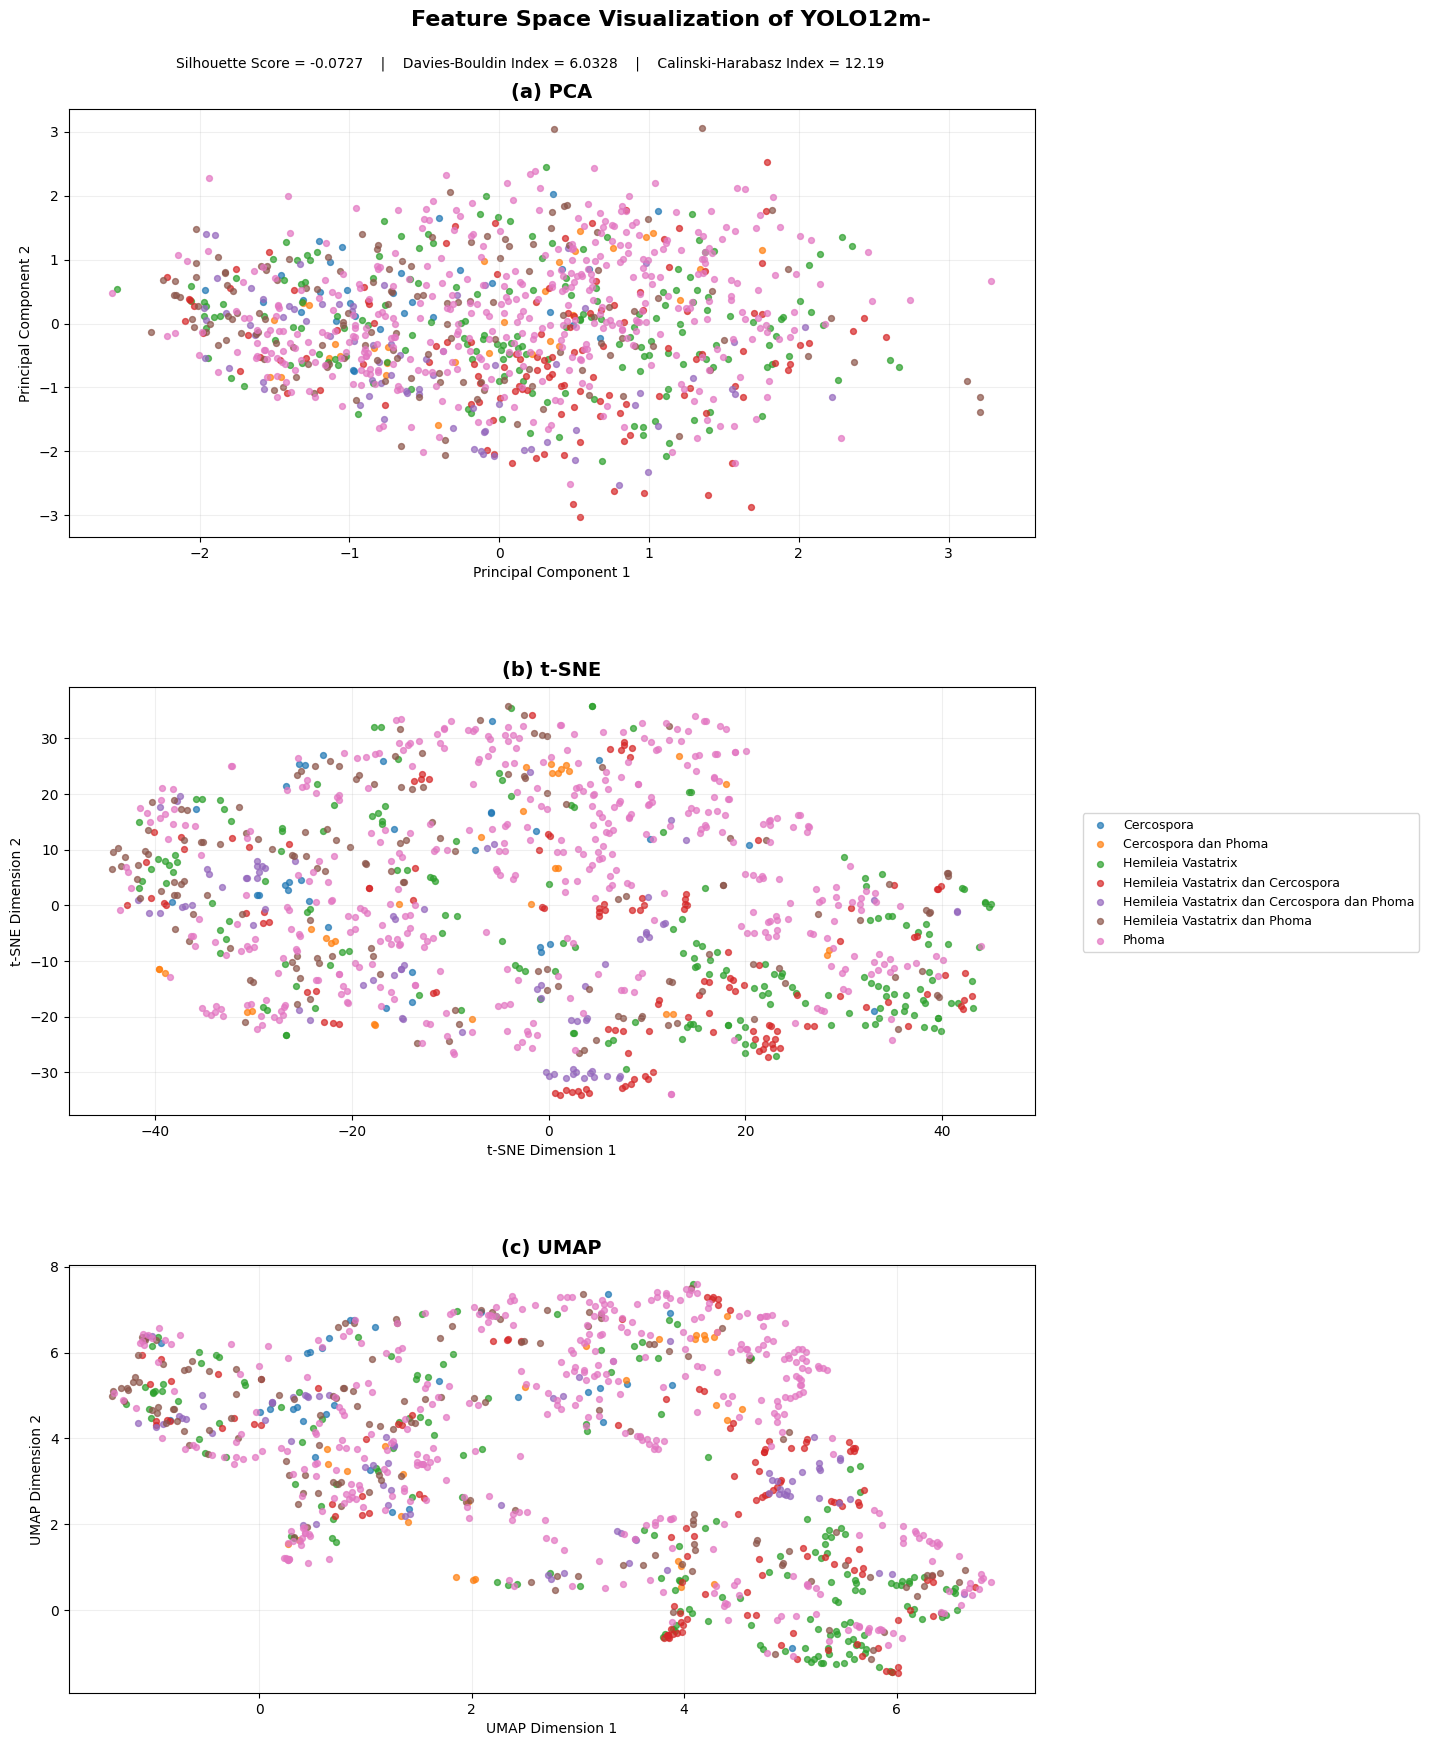

FIGURE BERHASIL DISIMPAN
/content/drive/MyDrive/feature_visualization_fold4/Feature_Space_YOLO12m_SqueezeNet_Fold4.png


In [52]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "/content/drive/MyDrive/feature_visualization_fold4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = [
    'Cercospora',
    'Cercospora dan Phoma',
    'Hemileia Vastatrix',
    'Hemileia Vastatrix dan Cercospora',
    'Hemileia Vastatrix dan Cercospora dan Phoma',
    'Hemileia Vastatrix dan Phoma',
    'Phoma'
]

plots = [
    (
        X_pca,
        "PCA",
        "Principal Component 1",
        "Principal Component 2"
    ),
    (
        X_tsne,
        "t-SNE",
        "t-SNE Dimension 1",
        "t-SNE Dimension 2"
    ),
    (
        X_umap,
        "UMAP",
        "UMAP Dimension 1",
        "UMAP Dimension 2"
    )
]

# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 18)
)

# =========================================================
# PLOT
# =========================================================

for i, (ax, plot_data) in enumerate(zip(axes, plots)):

    data = plot_data[0]
    method = plot_data[1]
    xlabel = plot_data[2]
    ylabel = plot_data[3]

    for class_id, class_name in enumerate(CLASS_NAMES):

        mask = y == class_id

        ax.scatter(
            data[mask, 0],
            data[mask, 1],
            s=18,
            alpha=0.70,
            label=class_name
        )

    ax.set_title(
        f"({chr(97 + i)}) {method}",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    ax.set_xlabel(
        xlabel,
        fontsize=10
    )

    ax.set_ylabel(
        ylabel,
        fontsize=10
    )

    ax.grid(
        True,
        alpha=0.20
    )

# =========================================================
# TITLE
# =========================================================

fig.suptitle(
    "Feature Space Visualization of YOLO12m-",
    fontsize=16,
    fontweight="bold",
    y=0.985
)

# =========================================================
# METRICS
# =========================================================

metric_text = (
    f"Silhouette Score = {silhouette:.4f}    |    "
    f"Davies-Bouldin Index = {dbi:.4f}    |    "
    f"Calinski-Harabasz Index = {chi:.2f}"
)

fig.text(
    0.40,
    0.955,
    metric_text,
    ha="center",
    va="center",
    fontsize=10
)

# =========================================================
# LEGEND DI SISI KANAN
# =========================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.79, 0.50),
    fontsize=9,
    frameon=True
)

# =========================================================
# ATUR POSISI
# =========================================================

fig.subplots_adjust(
    left=0.07,
    right=0.76,
    top=0.93,
    bottom=0.05,
    hspace=0.35
)

# =========================================================
# SAVE
# =========================================================

save_path = os.path.join(
    OUTPUT_DIR,
    "Feature_Space_YOLO12m_SqueezeNet_Fold4.png"
)

fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("==========================================")
print("FIGURE BERHASIL DISIMPAN")
print("==========================================")
print(save_path)

In [43]:
import numpy as np
import pandas as pd

class_distribution = []

for class_id, class_name in enumerate(CLASS_NAMES):

    count = np.sum(y == class_id)
    percentage = (count / len(y)) * 100

    class_distribution.append({
        "Class ID": class_id,
        "Class": class_name,
        "Instances": count,
        "Percentage": percentage
    })

distribution_df = pd.DataFrame(class_distribution)

print(distribution_df.to_string(index=False))

 Class ID                                       Class  Instances  Percentage
        0                                  Cercospora         31    3.075397
        1                        Cercospora dan Phoma         31    3.075397
        2                          Hemileia Vastatrix        179   17.757937
        3           Hemileia Vastatrix dan Cercospora        128   12.698413
        4 Hemileia Vastatrix dan Cercospora dan Phoma         75    7.440476
        5                Hemileia Vastatrix dan Phoma        143   14.186508
        6                                       Phoma        421   41.765873


**GRAD-CAM**

In [13]:
# Hapus hook feature extraction sebelumnya
try:
    hook.remove()
    print("Hook feature extraction lama berhasil dilepas.")
except:
    print("Hook lama tidak ditemukan, lanjut.")

Hook feature extraction lama berhasil dilepas.


In [16]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# RESET GRADIENT
# =========================================================

model.model.zero_grad()

# =========================================================
# TEST IMAGE
# =========================================================

test_images = sorted([
    f for f in os.listdir(TEST_IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

TEST_IMAGE = os.path.join(
    TEST_IMAGE_DIR,
    test_images[0]
)

print("Image:", TEST_IMAGE)

# =========================================================
# LOAD IMAGE
# =========================================================

img = cv2.imread(TEST_IMAGE)

if img is None:
    raise FileNotFoundError(TEST_IMAGE)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

original_h, original_w = img_rgb.shape[:2]

# Resize ke 640x640
img_resized = cv2.resize(
    img_rgb,
    (640, 640)
)

# =========================================================
# TENSOR
# =========================================================

input_tensor = (
    torch.from_numpy(img_resized)
    .permute(2, 0, 1)
    .float()
    .div(255.0)
    .unsqueeze(0)
    .to(device)
)

input_tensor.requires_grad_(True)

print("Input shape:", input_tensor.shape)
print("Device:", input_tensor.device)

Image: /content/drive/MyDrive/Dataset_Terbaru/data_coffe_augmentasi_derta/data/test/images/VID_20260403_163309_mp4-0016_jpg.rf.52b1ad244cd1c019771de9bee85daa27.jpg
Input shape: torch.Size([1, 3, 640, 640])
Device: cuda:0


In [17]:
# =========================================================
# STORAGE
# =========================================================

gradcam_activations = []
gradcam_gradients = []


# =========================================================
# FORWARD HOOK
# =========================================================

def forward_hook(module, input, output):

    gradcam_activations.append(output)


# =========================================================
# BACKWARD HOOK
# =========================================================

def backward_hook(module, grad_input, grad_output):

    gradcam_gradients.append(
        grad_output[0]
    )


# =========================================================
# LAYER 8
# =========================================================

target_layer = model.model.model[8]

forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

print("Grad-CAM hook berhasil dipasang.")
print("Target layer:", target_layer)

Grad-CAM hook berhasil dipasang.
Target layer: Sequential(
  (0): Fire(
    (squeeze): Conv(
      (conv): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (expand1): Conv(
      (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (expand3): Conv(
      (conv): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
  )
  (1): Fire(
    (squeeze): Conv(
      (conv): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): Si

In [18]:
# =========================================================
# FORWARD
# =========================================================

model.model.eval()
model.model.zero_grad()

gradcam_activations.clear()
gradcam_gradients.clear()

output = model.model(input_tensor)

print("Output type:", type(output))

if isinstance(output, tuple):

    print("Jumlah output:", len(output))

    for i, item in enumerate(output):

        if torch.is_tensor(item):

            print(
                f"Output[{i}] shape:",
                item.shape,
                "| requires_grad:",
                item.requires_grad
            )

        else:

            print(
                f"Output[{i}] type:",
                type(item)
            )

elif torch.is_tensor(output):

    print(
        "Output shape:",
        output.shape,
        "| requires_grad:",
        output.requires_grad
    )

print("\nActivation Layer 8:")

if len(gradcam_activations) > 0:

    activation = gradcam_activations[0]

    print("Activation shape:", activation.shape)
    print("Requires grad:", activation.requires_grad)

else:

    print("ERROR: activation tidak tertangkap.")

Output type: <class 'tuple'>
Jumlah output: 2
Output[0] shape: torch.Size([1, 11, 8400]) | requires_grad: True
Output[1] type: <class 'dict'>

Activation Layer 8:
Activation shape: torch.Size([1, 512, 20, 20])
Requires grad: True


In [19]:
# =========================================================
# AMBIL TARGET SCORE UNTUK GRAD-CAM
# =========================================================

# Output YOLO:
# [batch, 4 + jumlah kelas, jumlah kandidat]

predictions = output[0]

print("Prediction shape:", predictions.shape)

# Ambil bagian class score
class_scores = predictions[:, 4:, :]

print("Class score shape:", class_scores.shape)

# Cari score tertinggi
target_score, target_index = torch.max(
    class_scores.reshape(-1),
    dim=0
)

print("Target score :", target_score.item())
print("Target index :", target_index.item())

Prediction shape: torch.Size([1, 11, 8400])
Class score shape: torch.Size([1, 7, 8400])
Target score : 0.9407655596733093
Target index : 6752


In [20]:
# =========================================================
# BACKPROPAGATION
# =========================================================

model.model.zero_grad()

gradcam_gradients.clear()

target_score.backward(
    retain_graph=True
)

print("Backward berhasil.")
print("Jumlah gradient:", len(gradcam_gradients))

Backward berhasil.
Jumlah gradient: 1


In [21]:
# =========================================================
# CEK GRADIENT
# =========================================================

if len(gradcam_gradients) == 0:
    raise RuntimeError(
        "Gradient tidak tertangkap pada Layer 8."
    )

gradient = gradcam_gradients[0]
activation = gradcam_activations[0]

print("Activation shape :", activation.shape)
print("Gradient shape   :", gradient.shape)
print("Gradient min     :", gradient.min().item())
print("Gradient max     :", gradient.max().item())

Activation shape : torch.Size([1, 512, 20, 20])
Gradient shape   : torch.Size([1, 512, 20, 20])
Gradient min     : -0.0007159864762797952
Gradient max     : 0.0007924504461698234


In [22]:
# =========================================================
# HITUNG GRAD-CAM
# =========================================================

activation = activation.detach()
gradient = gradient.detach()

# Bobot setiap channel
weights = gradient.mean(
    dim=(2, 3),
    keepdim=True
)

print("Weights shape:", weights.shape)

# Kombinasikan activation dengan bobot
cam = (weights * activation).sum(
    dim=1
)

# ReLU
cam = torch.relu(cam)

# Hilangkan batch dimension
cam = cam.squeeze().cpu().numpy()

print("CAM shape:", cam.shape)
print("CAM min:", cam.min())
print("CAM max:", cam.max())

Weights shape: torch.Size([1, 512, 1, 1])
CAM shape: (20, 20)
CAM min: 0.0
CAM max: 5.360849e-05


In [23]:
# =========================================================
# NORMALISASI CAM
# =========================================================

cam = cam - cam.min()

if cam.max() > 0:
    cam = cam / cam.max()

# Resize ke ukuran gambar asli
cam_resized = cv2.resize(
    cam,
    (original_w, original_h)
)

# =========================================================
# HEATMAP
# =========================================================

heatmap = np.uint8(
    255 * cam_resized
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

# =========================================================
# OVERLAY
# =========================================================

overlay = (
    0.45 * heatmap +
    0.55 * img_rgb
)

overlay = np.uint8(
    np.clip(overlay, 0, 255)
)

print("Grad-CAM berhasil dibuat.")

Grad-CAM berhasil dibuat.


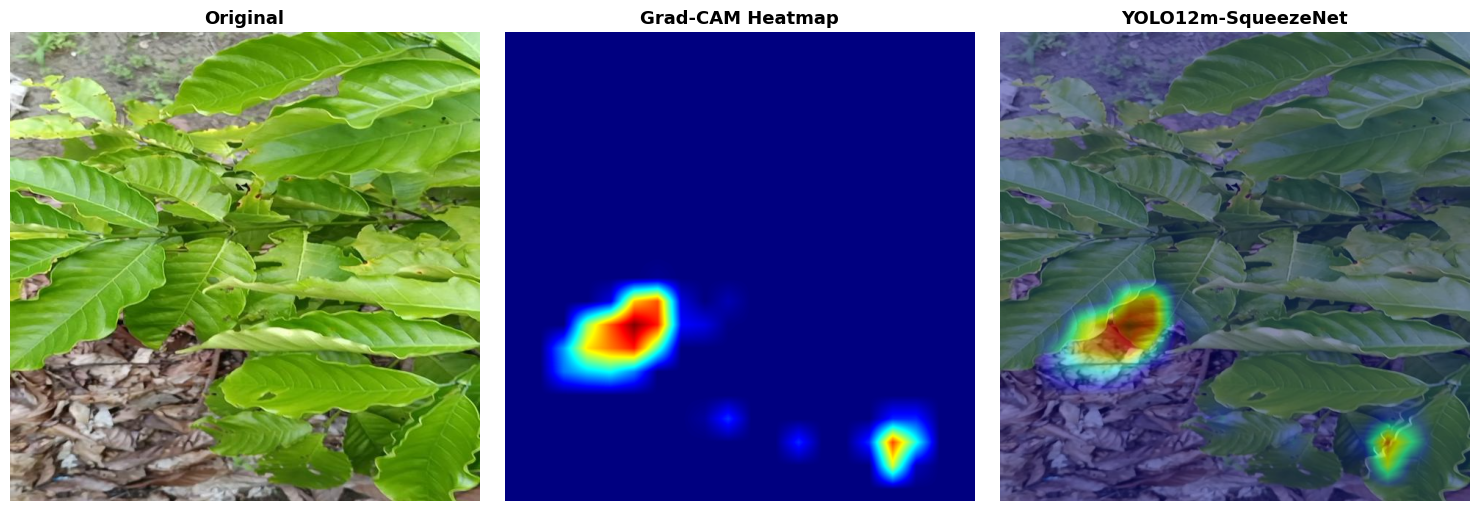

In [24]:
# =========================================================
# VISUALISASI
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(img_rgb)
axes[0].set_title(
    "Original",
    fontsize=13,
    fontweight="bold"
)
axes[0].axis("off")


axes[1].imshow(heatmap)
axes[1].set_title(
    "Grad-CAM Heatmap",
    fontsize=13,
    fontweight="bold"
)
axes[1].axis("off")


axes[2].imshow(overlay)
axes[2].set_title(
    "YOLO12m-SqueezeNet",
    fontsize=13,
    fontweight="bold"
)
axes[2].axis("off")


plt.tight_layout()
plt.show()

In [25]:
from ultralytics import YOLO
import torch

# Ganti dengan lokasi best.pt YOLO12m standar kamu
BEST_PT_M = "/content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m/yolo12m_fold_2/weights/best.pt"

model_m = YOLO(BEST_PT_M)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_m.model.to(device)
model_m.model.eval()

print("Device :", device)
print("Model  :", BEST_PT_M)

Device : cuda
Model  : /content/drive/MyDrive/train_yolo_data_augmentasi/Yolo12m/yolo12m_fold_2/weights/best.pt


In [26]:
for i, layer in enumerate(model_m.model.model):
    print(f"[{i}] {layer.__class__.__name__}")

[0] Conv
[1] Conv
[2] C3k2
[3] Conv
[4] C3k2
[5] Conv
[6] A2C2f
[7] Conv
[8] A2C2f
[9] Upsample
[10] Concat
[11] A2C2f
[12] Upsample
[13] Concat
[14] A2C2f
[15] Conv
[16] Concat
[17] A2C2f
[18] Conv
[19] Concat
[20] C3k2
[21] Detect


In [27]:
# =========================================================
# GRAD-CAM YOLO12m STANDARD
# TARGET: LAYER 8 (A2C2f)
# =========================================================

gradcam_activations_m = []
gradcam_gradients_m = []


def forward_hook_m(module, input, output):

    # Simpan activation
    if isinstance(output, torch.Tensor):
        gradcam_activations_m.append(output)

        # Simpan gradient dari activation
        output.register_hook(
            lambda grad: gradcam_gradients_m.append(grad)
        )


hook_m = model_m.model.model[8].register_forward_hook(
    forward_hook_m
)

print("Hook berhasil dipasang pada YOLO12m Layer 8.")

Hook berhasil dipasang pada YOLO12m Layer 8.


In [29]:
# =========================================================
# FORWARD YOLO12m
# =========================================================

model_m.model.zero_grad()

gradcam_activations_m.clear()
gradcam_gradients_m.clear()

output_m = model_m.model(input_tensor)

print("Forward YOLO12m selesai.")
print("Jumlah activation:", len(gradcam_activations_m))

if len(gradcam_activations_m) > 0:
    print(
        "Activation shape:",
        gradcam_activations_m[0].shape
    )

Forward YOLO12m selesai.
Jumlah activation: 1
Activation shape: torch.Size([1, 512, 20, 20])


In [31]:
# =========================================================
# YOLO12m - FORWARD + BACKWARD UNTUK GRAD-CAM
# =========================================================

# Bersihkan gradient sebelumnya
model_m.model.zero_grad(set_to_none=True)

# Bersihkan hasil hook sebelumnya
gradcam_activations_m.clear()
gradcam_gradients_m.clear()

# Forward
output_m = model_m.model(input_tensor)

print("Forward selesai.")
print("Jumlah activation :", len(gradcam_activations_m))

# Ambil output prediksi utama
pred = output_m[0]

print("Prediction shape :", pred.shape)

# =========================================================
# AMBIL CLASS SCORE
# =========================================================

# YOLO12 output:
# 4 channel pertama = bounding box
# channel berikutnya = class scores

class_scores = pred[:, 4:, :]

print("Class score shape :", class_scores.shape)

# Ambil score prediksi paling tinggi
target_score = class_scores.max()

print("Target score :", target_score.item())

# =========================================================
# BACKWARD
# =========================================================

target_score.backward()

print("Backward selesai.")
print("Jumlah gradient :", len(gradcam_gradients_m))

# =========================================================
# CEK GRADIENT
# =========================================================

if len(gradcam_gradients_m) > 0:

    print(
        "Gradient shape :",
        gradcam_gradients_m[0].shape
    )

else:

    print("ERROR: Gradient masih kosong.")

Forward selesai.
Jumlah activation : 1
Prediction shape : torch.Size([1, 11, 8400])
Class score shape : torch.Size([1, 7, 8400])
Target score : 0.949977457523346
Backward selesai.
Jumlah gradient : 1
Gradient shape : torch.Size([1, 512, 20, 20])


In [32]:
# =========================================================
# HITUNG GRAD-CAM YOLO12m
# =========================================================

activation = gradcam_activations_m[0]
gradient = gradcam_gradients_m[0]

print("Activation :", activation.shape)
print("Gradient   :", gradient.shape)

# Global Average Pooling pada gradient
weights = gradient.mean(dim=(2, 3), keepdim=True)

# Weighted combination
gradcam = (weights * activation).sum(dim=1, keepdim=True)

# ReLU
gradcam = torch.relu(gradcam)

# Normalisasi 0-1
gradcam = gradcam - gradcam.min()
gradcam = gradcam / (gradcam.max() + 1e-8)

print("Grad-CAM shape:", gradcam.shape)

Activation : torch.Size([1, 512, 20, 20])
Gradient   : torch.Size([1, 512, 20, 20])
Grad-CAM shape: torch.Size([1, 1, 20, 20])


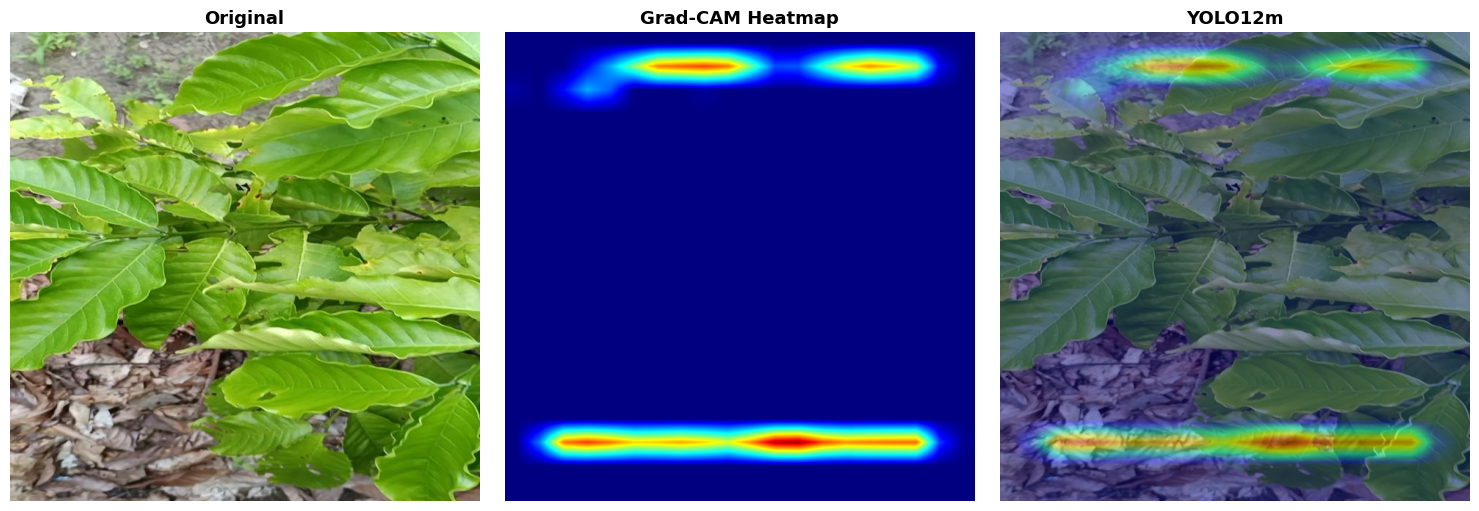

In [33]:
# =========================================================
# VISUALISASI GRAD-CAM YOLO12m
# =========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ambil Grad-CAM
cam = gradcam[0, 0].detach().cpu().numpy()

# Resize ke ukuran gambar
cam_resized = cv2.resize(
    cam,
    (640, 640),
    interpolation=cv2.INTER_LINEAR
)

# Ubah menjadi heatmap
heatmap = np.uint8(255 * cam_resized)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

# OpenCV BGR -> RGB
heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

# Gambar asli
original = cv2.cvtColor(
    img_rgb,
    cv2.COLOR_RGB2BGR
)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = cv2.addWeighted(
    original,
    0.55,
    heatmap,
    0.45,
    0
)

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(original)
axes[0].set_title(
    "Original",
    fontsize=13,
    fontweight="bold"
)
axes[0].axis("off")

axes[1].imshow(heatmap)
axes[1].set_title(
    "Grad-CAM Heatmap",
    fontsize=13,
    fontweight="bold"
)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(
    "YOLO12m",
    fontsize=13,
    fontweight="bold"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()